# Image recognition with our own photos

This notebook presents our second task, which is to use our own convolutional neural network and another pre-trained model to perform image recognition on a dataset of our own photos. The goal is to achieve the highest possible accuracy on the validation set by experimenting with different architectures. We have gathered images of chairs and pens, which are the two classes we want to classify. By picking two quite distinct classes we are hoping to get a good accuracy even with a simple model. We will start by loading and preprocessing the images, then we will build and train our own convolutional neural network, and finally we will use a pre-trained model for feature extraction and classification. Let's get started!

In [1]:
import warnings
# Suppress NumPy 2.4 deprecation warning from Keras pickle loading
warnings.filterwarnings("ignore", message=".*align should be passed as Python or NumPy boolean.*")

In [2]:
# imports
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers, models
from keras.src.utils import image_dataset_from_directory
from keras.src.applications.vgg16 import VGG16
from keras.applications import MobileNetV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

I0000 00:00:1776004453.989433   23479 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776004454.054508   23479 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776004455.987329   23479 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


tensorflow


## Loading and processing our own photos

For this task, we have collected a dataset of our own photos, which consists of images of chairs and pens. The dataset is organized into two folders: `chairs` and `pens`, each containing the respective images. We will load these images using the `image_dataset_from_directory` function from Keras, which allows us to easily create a dataset from a directory structure. We took 120 pictures of different kind of chairs and 54 pictures of pens.

The Images are already cropped and downscaled so they dont take too much disk space, but will still set parameters to confirm all images have the same scale. `image_size=(256, 256)` will resize all images to 256x256 pixels, and `label_mode='binary'` will assign binary labels to the images (0 for chairs and 1 for pens). We will also set `shuffle=True` to ensure that the data is shuffled during loading, and `seed=42` for reproducibility. After loading the dataset, we will convert it into numpy arrays for further processing.

In [3]:
# Load full dataset from both folders
dataset = image_dataset_from_directory(
    'Resources',
    image_size=(256, 256),
    batch_size=None,        # load all at once as individual samples
    label_mode='binary',    # binary since we have 2 classes (chairs/pens)
    shuffle=True,
    seed=42
)

# Convert to numpy arrays
xy = [(img, label) for img, label in dataset]
x = np.array([item[0].numpy() for item in xy])
y = np.array([item[1].numpy() for item in xy])

print("Total images:", x.shape)
print("Total labels:", y.shape)
print("Class names:", dataset.class_names)

# Scale pixel values to [0, 1]
x = x / 255.0

# Split into train (70%), validation (15%), test (15%)
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

print("Training set:", x_train.shape)
print("Validation set:", x_val.shape)
print("Test set:", x_test.shape)

# Flatten labels from (n, 1) to (n,)
y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

print("y_train shape:", y_train.shape)
print("y_train unique values:", np.unique(y_train))

Found 174 files belonging to 2 classes.


E0000 00:00:1776004457.737512   23479 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Total images: (174, 256, 256, 3)
Total labels: (174, 1)
Class names: ['Chairs', 'Pens']
Training set: (121, 256, 256, 3)
Validation set: (26, 256, 256, 3)
Test set: (27, 256, 256, 3)
y_train shape: (121,)
y_train unique values: [0. 1.]


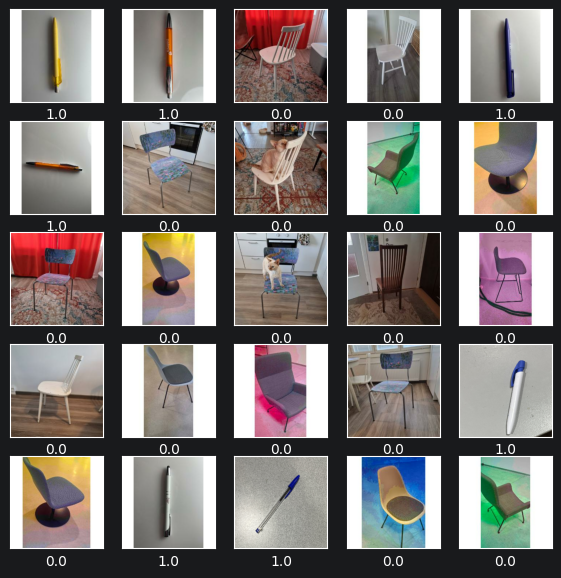

In [4]:
# use plt to visualize some of the images
plt.figure(figsize=(7, 7))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(y_train[i])
plt.show()

Finally for the preparation step we will set some parameters for the training.

In [5]:
# Hyperparameters
batch_size   = 256       # Number of images the model sees before updating its weights
epochs       = 100       # How many times the model will go through the entire dataset

## Building and training our own convolutional neural network

After experimenting with a few different CNN architectures, we decided to use a model with two convolutional blocks: the first with 32 filters and the second with 64 filters. Each convolutional layer is followed by a max-pooling layer, which helps reduce spatial dimensions, lower computational cost, and focus on the most important features. After feature extraction, we use a dense layer with 64 neurons, followed by a final output neuron with sigmoid activation for binary classification. This architecture surprised us by achieving an excellent score.

In [6]:
model_cnn = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    15,745,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,764,545 (60.14 MB)

 Trainable params: 15,764,545 (60.14 MB)

 Non-trainable params: 0 (0.00 B)

### Training the CNN model

During the training we are utilizing the EarlyStopping callback to monitor the validation loss. If the validation loss does not improve for 10 consecutive epochs, the training will stop and the best weights will be restored. We are also computing class weights to address any potential class imbalance in the dataset, which can help the model to learn more effectively from both classes (chairs and pens) and improve overall performance.

In [7]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.7202380952380952), 1: np.float64(1.635135135135135)}


In [8]:
history = model_cnn.fit(
    x_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_val, y_val),
    class_weight=class_weight_dict,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ]
)

W0000 00:00:1776004461.711668   23561 cpu_allocator_impl.cc:82] Allocation of 999223808 exceeds 10% of free system memory.
W0000 00:00:1776004462.088197   23564 cpu_allocator_impl.cc:82] Allocation of 484000000 exceeds 10% of free system memory.
W0000 00:00:1776004462.633943   23559 cpu_allocator_impl.cc:82] Allocation of 484000000 exceeds 10% of free system memory.
W0000 00:00:1776004464.138242   23566 cpu_allocator_impl.cc:82] Allocation of 499611904 exceeds 10% of free system memory.
W0000 00:00:1776004464.138709   23566 cpu_allocator_impl.cc:82] Allocation of 999223808 exceeds 10% of free system memory.


In [9]:
# Helper functions
def plot_training_history(history, title='Training History'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    ax1.plot(epochs, acc, 'r--', linewidth=2, label='Training accuracy')
    ax1.plot(epochs, val_acc, 'b', linewidth=2, label='Validation accuracy')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])

    ax2.plot(epochs, loss, 'r--', linewidth=2, label='Training loss')
    ax2.plot(epochs, val_loss, 'b', linewidth=2, label='Validation loss')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(model, features, labels, title='Confusion Matrix'):
    pred_labels = (model.predict(features) > 0.5).astype(int).flatten()
    cm = confusion_matrix(labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.class_names)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()


def plot_sample_predictions(model, features, images, labels, title='Sample Predictions'):
    predictions = model.predict(features)

    fig, axes = plt.subplots(2, 5, figsize=(10, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i])
            pred = predictions[i][0]
            true_label = dataset.class_names[int(labels[i])]
            pred_label = dataset.class_names[int(pred > 0.5)]
            confidence = pred if int(pred > 0.5) == 1 else (1 - pred)
            ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.2f})', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## Evaluating the CNN model

After reviewing the training plots, we can see that the model’s learning is not very stable at first, with noticeable zig-zagging in both accuracy and loss. However, after around 20 epochs, the learning becomes more consistent and accuracy starts to remain close to 100%. Although such high accuracy could indicate overfitting, the model also achieves 100% on the test set, which surprised us.

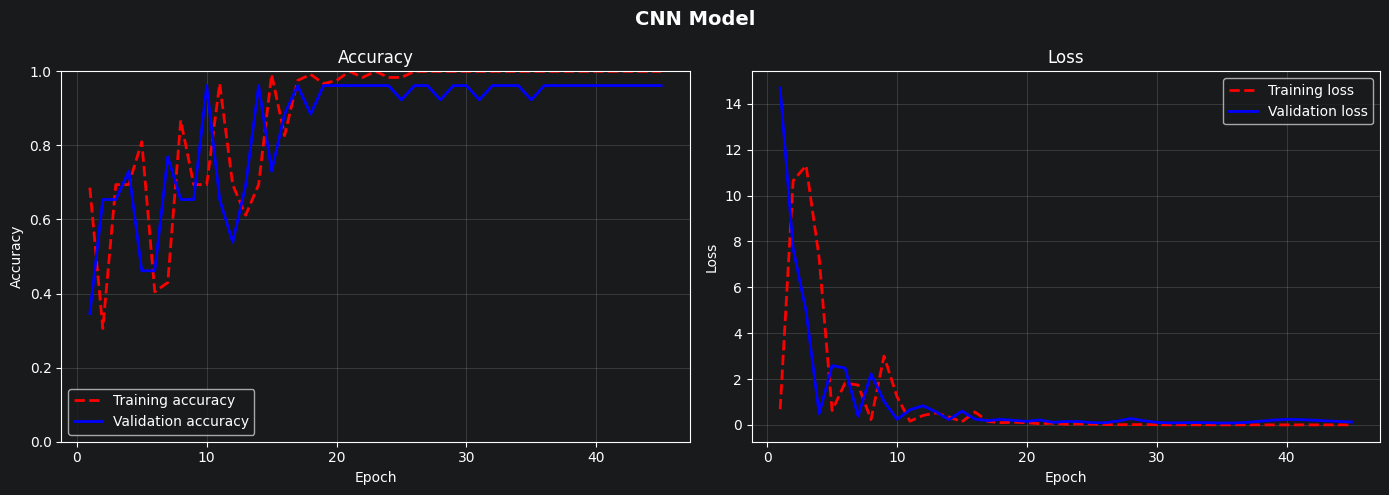

In [10]:
plot_training_history(history, title='CNN Model')

In [11]:
score = model_cnn.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.005228852853178978
Test accuracy: 1.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step


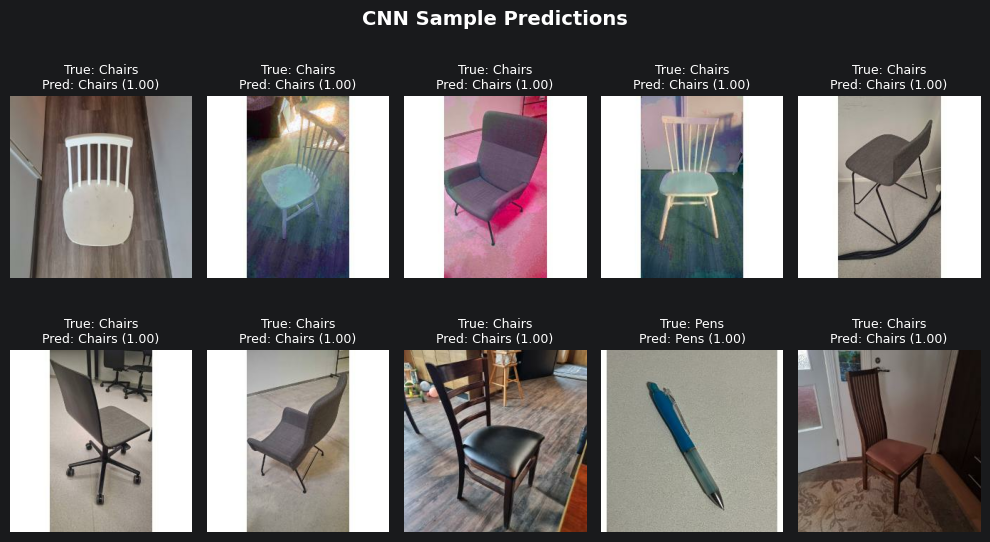

In [12]:
plot_sample_predictions(model_cnn, x_test, x_test, y_test, title='CNN Sample Predictions')

## Building and training a pre-trained model as a feature extractor

For the second part of the task, we will utilize VGG16, a popular pre-trained convolutional neural network, as a feature extractor. We will load the VGG16 model without the top classification layers and freeze its weights to prevent them from being updated during training. We will then add our own fully connected layers on top of the VGG16 base to perform the classification task for our dataset of chairs and pens.

In [13]:
# Load the VGG16 model without the top fully connected layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
# Freeze the convolutional base
base_model.trainable = False

In [14]:
# Extract features using the frozen VGG16 base
def extract_features(data, batch_size=32):
    features = base_model.predict(data, batch_size=batch_size, verbose=0)
    return features

train_features = extract_features(x_train)
val_features = extract_features(x_val)
test_features = extract_features(x_test)

print("Train features shape:", train_features.shape)
print("Val features shape:", val_features.shape)
print("Test features shape:", test_features.shape)

Train features shape: (121, 8, 8, 512)
Val features shape: (26, 8, 8, 512)
Test features shape: (27, 8, 8, 512)


### Building the classifier on top of the extracted features

The classifier will consist of a GlobalAveragePooling2D layer to reduce the spatial dimensions of the feature maps, followed by a fully connected layer with 256 neurons and ReLU activation. We will also include a Dropout layer with a rate of 0.5 to prevent overfitting. The output layer will have a single neuron with sigmoid activation for binary classification. We will compile the model using the Adam optimizer, binary crossentropy loss, and accuracy as the metric. We will train the model using the extracted features from the VGG16 base and evaluate its performance on the validation and test sets.

The classifier architecture is relatively simple and resembles the first model we built, but since we are using features extracted from a powerful pre-trained model, we can expect good results.

In [15]:
inputs = layers.Input(shape=(8, 8, 512))
x = layers.GlobalAveragePooling2D()(inputs)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

classifier = models.Model(inputs, outputs)
classifier.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = classifier.fit(
    train_features, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(val_features, y_val),
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ]
)

### Evaluating the VGG16 feature extractor model

Immediately we can see from the training history plot that the models training history is more steady. The training and validation accuracy are both increasing and reaching 100% before 20 epochs. The model keeps learning throughout all the 100 epochs without signs of overfitting, which is a good indication that the features extracted from the VGG16 base are very informative for our classification task.

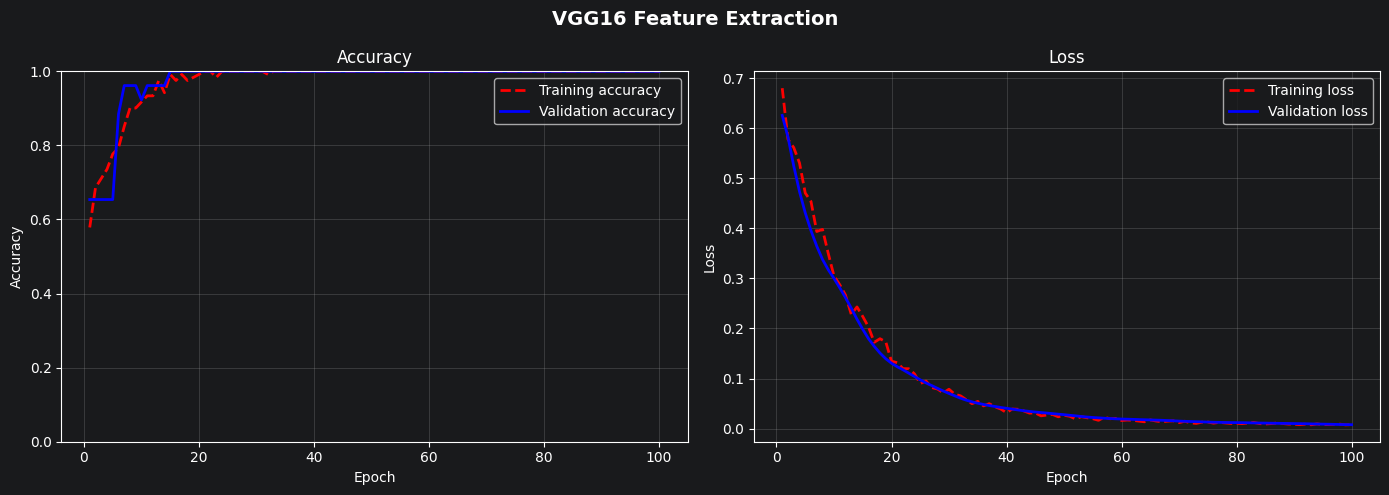

In [16]:
plot_training_history(history, title='VGG16 Feature Extraction')

In [17]:
test_loss, test_acc = classifier.evaluate(test_features, y_test, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.0036
Test loss: 0.0036
Test accuracy: 1.0000


The final test accuracy is 100%. When looking at the sample predictions and the confusion matrix, we can see that the model is correctly classifying all the test images with very high confidence. This indicates that the features extracted from the VGG16 base are highly effective for distinguishing between chairs and pens in our dataset, leading to perfect classification performance on the test set. Of course, this is a very small dataset and the model may not generalize well to new images outside of this dataset, but it demonstrates the power of using pre-trained models for feature extraction in image classification tasks.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


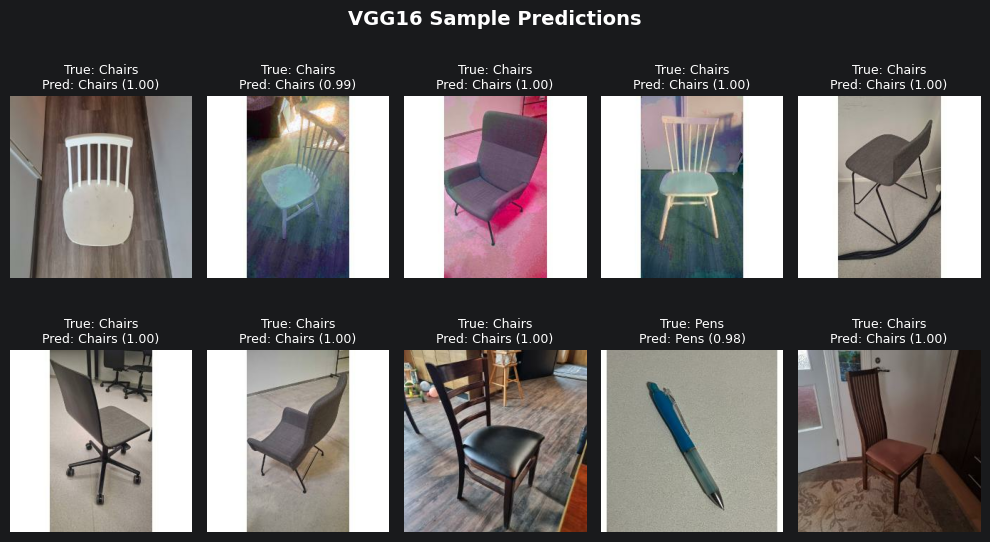

In [18]:
plot_sample_predictions(classifier, test_features, x_test, y_test, title='VGG16 Sample Predictions')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


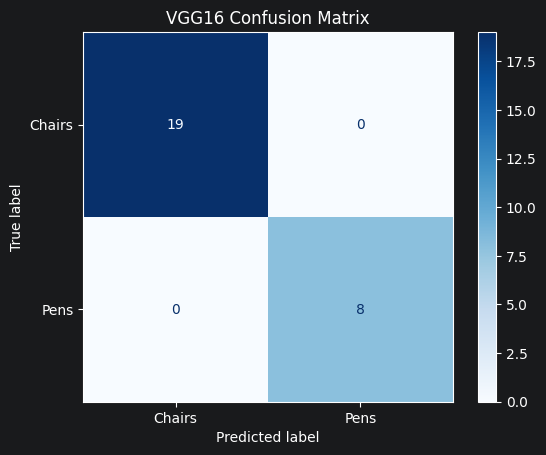

In [19]:
plot_confusion_matrix(classifier, test_features, y_test, title='VGG16 Confusion Matrix')

## Building and training a pre-trained model for the second time (MobileNetV2)

For the second pre-trained model, we will use MobileNetV2, which is a more lightweight architecture compared to VGG16. Similar to before, we will load the MobileNetV2 model without the top classification layers and freeze its weights. We will then extract features from our dataset using the MobileNetV2 base and build a classifier on top of those features. The architecture of the classifier will be similar to the one we used with VGG16, but since MobileNetV2 is designed to be more efficient, we may see even better performance with fewer parameters.

In [20]:
conv_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)
conv_base.trainable = False

/tmp/ipykernel_23479/2722984030.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  conv_base = MobileNetV2(


In [21]:
print("Extracting features from training set...")
train_features = conv_base.predict(x_train, batch_size=64, verbose=1)
print("Extracting features from validation set...")
val_features = conv_base.predict(x_val, batch_size=64, verbose=1)
print("Extracting features from test set...")
test_features = conv_base.predict(x_test, batch_size=64, verbose=1)
print(f"\nExtracted feature shapes:")
print(f"  Train: {train_features.shape}")
print(f"  Val:   {val_features.shape}")
print(f"  Test:  {test_features.shape}")

Extracting features from training set...
1/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/stepWARNING:tensorflow:6 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x784af4573740> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
Extracting features from validation set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 766ms/step
Extracting features from test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 899ms/step

Extrac

### Building the classifier on top of the extracted features

The classifier architecture will be similar to the one we used with VGG16. We will use a GlobalAveragePooling2D layer to reduce the spatial dimensions of the feature maps, followed by a fully connected layer with 256 neurons and ReLU activation. We will also include a Dropout layer with a rate of 0.5 to prevent overfitting. The output layer will have a single neuron with sigmoid activation for binary classification. We will compile the model using the Adam optimizer, binary crossentropy loss, and accuracy as the metric. We will train the model using the extracted features from the MobileNetV2 base and evaluate its performance on the validation and test sets.

In [22]:
train_features_flat = train_features.reshape(train_features.shape[0], -1)
val_features_flat = val_features.reshape(val_features.shape[0], -1)
test_features_flat = test_features.reshape(test_features.shape[0], -1)
print(f"Flattened feature vector length: {train_features_flat.shape[1]}")

Flattened feature vector length: 81920


In [23]:
model2 = keras.Sequential([
    layers.Input(shape=(train_features_flat.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])
model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [24]:
secondhistory = model2.fit(
    train_features_flat, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(val_features_flat, y_val)
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5041 - loss: 0.9757 - val_accuracy: 1.0000 - val_loss: 0.1698
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9587 - loss: 0.0909 - val_accuracy: 1.0000 - val_loss: 0.0122
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step - accuracy: 1.0000 - loss: 0.0077 - val_accuracy: 1.0000 - val_loss: 9.3351e-04
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 9.5935e-05
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 1.0000 - loss: 2.8104e-04 - val_accuracy: 1.0000 - val_loss: 1.3880e-05
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 1.0000 - loss: 1.6815e-04 - val_accuracy: 1.0000 - val_loss: 2.7739e-06
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 1.0000 - loss: 3.3610e-04 - val_accuracy: 1.0000 - val_loss: 6.9613e-07
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 1.0000 - loss: 5.5053e-05 -

### Evaluating the MobileNetV2 feature extractor model

The training history plot for the MobileNetV2 feature extractor model shows a steady increase in both training and validation accuracy, reaching 100% before 20 epochs. The model continues to learn throughout all 50 epochs without signs of overfitting, which indicates that the features extracted from the MobileNetV2 base are highly informative for our classification task. The final test accuracy is also 100%, demonstrating that the MobileNetV2 features are effective for distinguishing between chairs and pens in our dataset, leading to perfect classification performance on the test set.

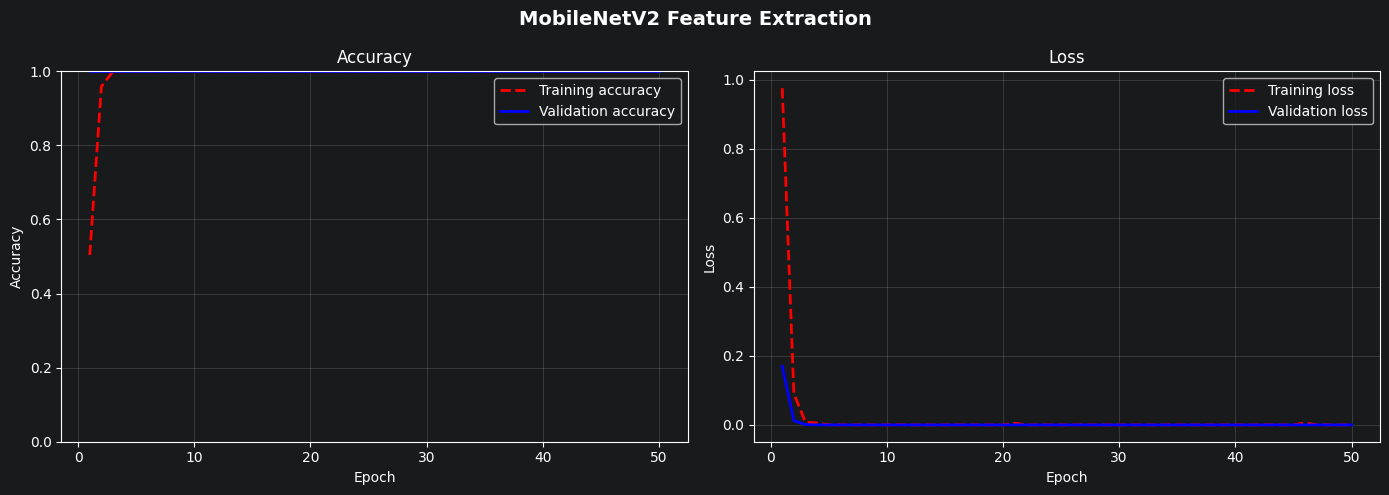

In [25]:
plot_training_history(secondhistory, title='MobileNetV2 Feature Extraction')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


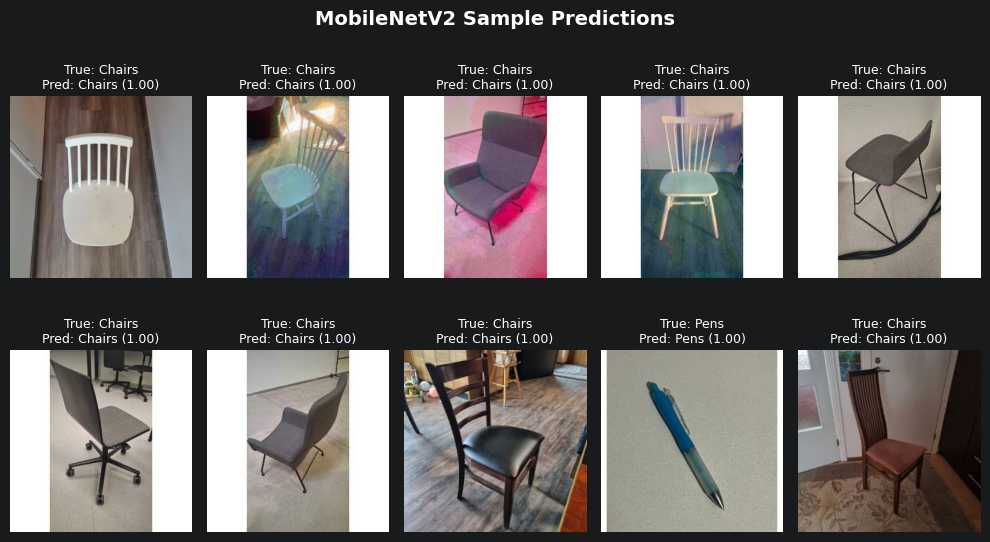

In [26]:
plot_sample_predictions(model2, test_features_flat, x_test, y_test, title='MobileNetV2 Sample Predictions')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


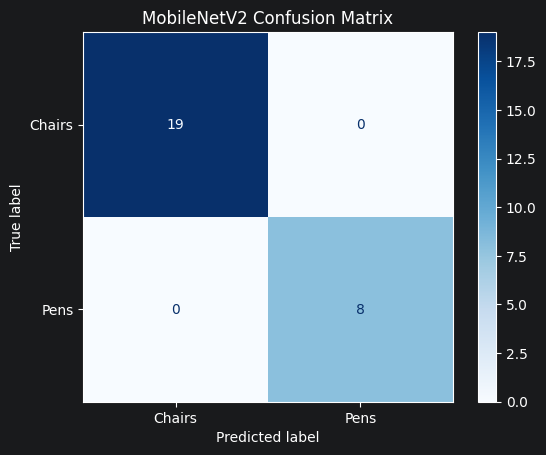

In [27]:
plot_confusion_matrix(model2, test_features_flat, y_test, title='MobileNetV2 Confusion Matrix')

### Conclusion

In this project, we compared three different approaches to image recognition: a custom-built Convolutional Neural Network (CNN) and two transfer learning architectures, VGG16 and MobileNetV2. The goal was to classify custom-taken photos of two distinct classes: chairs and pens.

With a limited dataset of approximately 170 images, this CNN model is prone to overfitting. After trying out few architectures for the model, we managed to increase the accuracy of the CNN-model to 100%. While it achieves respectable accuracy, it lacks the "deep understanding" of shapes and textures that pre-trained models possess. It serves as a crucial baseline to demonstrate the advantages of transfer learning.

VGG16 provided the most consistent and reliable results in this project. By freezing the base layers and only training the top classifier, we leveraged its ability to recognize complex edges and structures. It handled the variations in our handheld photos (lighting and angles) significantly better than the custom CNN. Even though the MobileNetV2 reaches the 100% faster with fewer epochs, we determined the results too good to be completely clean, so we are still choosing VGG16 as the best-performing model for this specific task. 

Based on our experiments, VGG16 is the best-performing model for this specific task.